# Demo -- PARNET embeddings (splice donor/acceptor sites, spliceosome HepG2)

Loads the precomputed fine-tuned PARNET model (`spliceosome-hepg2.precomputed`) and asks:
**do donor and acceptor splice sites separate in embedding space?**

Pipeline: MANE GFF (chr8 subset, a held-out test chromosome) -> strand-aware donor/acceptor
extraction -> 600nt genomic window per site -> PARNET backbone embedding (stem+body, no head) ->
central-window mean-pooling -> PCA -> UMAP.

Sites are also annotated with proximity to PRPF8 / U2AF2 HepG2 eCLIP peaks (chr8 subset), tying
the embedding story back to the two RBPs of interest for this demo.

## Set-up

### Imports

In [1]:
import pylbsr.notebooks
import pylbsr.misc
from pylbsr.plotting import setup_mpl_everything
from pylbsr.bio.sequence_window import fetch_windowed_sequence

import numpy as np
import pandas as pd
import pyfaidx
import torch
import umap
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from dotmap import DotMap
from sklearn.decomposition import PCA
from tqdm import tqdm

import parnet.utils
from parnet_additional_utils import load_parnet_model_from_statedict, ParnetModelName
from parnet_demo_utils import prepare_chr8_gff, prepare_chr8_splice_sites, prepare_chr8_peaks


2026-07-09 12:11:04.965017: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-09 12:11:04.973046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-09 12:11:04.985043: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-09 12:11:04.985062: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-09 12:11:04.993453: I tensorflow/core/platform/cpu_feature_gua

### Initialization

In [2]:
_notebook_name = "embeddings.py.ipynb"
_notebook_path = f"notebooks/demo--train-spliceosome-hepg2/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)

logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

setup_mpl_everything(font="Arial")


[12:11:07] INFO - Project directory: /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models


### Parameters

In [ ]:
params_gpu_index = 0

# Precomputed fine-tuned model to load (see results/spliceosome-hepg2.precomputed/).
params_run_id = "parnet.7m-0.0.ft-head.spliceosome-hepg2"

# Window size passed through the model (matches the model's native training window).
params_window_size = 600

# Half-width (nt) of the central window mean-pooled into a single embedding vector per site.
params_pool_half_width = 5

# Splice sites farther than this from any PRPF8/U2AF2 peak are labelled "none" in the peak-proximity plot.
params_peak_proximity_threshold = 50

params_batch_size = 256

# Source resources used to build results/spliceosome-hepg2.precomputed/extracted_datasets/.
# Mirrored locally under local_resources/external/ (originally NAS-hosted) -- see
# local_resources/README or config/filepaths.lambosaur-ms-01-2.yaml for provenance.
PARAMS_MANE_GFF = str(
    PROJECT_DIR / "local_resources" / "external" / "mane" / "MANE.GRCh38.v1.4.ensembl_genomic.gff"
)
PARAMS_NARROWPEAK_PATHS = {
    "PRPF8_HepG2": str(
        PROJECT_DIR
        / "local_resources"
        / "external"
        / "parnet_encore_eclip"
        / "bed10_peaks_narrowpeaks"
        / "PRPF8_HepG2"
        / "narrowPeak.1_1-2_1.bed.gz"
    ),
    "U2AF2_HepG2": str(
        PROJECT_DIR
        / "local_resources"
        / "external"
        / "parnet_encore_eclip"
        / "bed10_peaks_narrowpeaks"
        / "U2AF2_HepG2"
        / "narrowPeak.1_1-2_1.bed.gz"
    ),
}
PARAMS_GENOME_FASTA = str(PROJECT_DIR / "local_resources" / "external" / "genome" / "hg38.fa")
PARAMS_CHROM_SIZES = str(
    PROJECT_DIR / "local_resources" / "external" / "genome" / "hg38.chrom.sizes"
)

In [4]:
# NOTE: THIS CELL MIGHT REQUIRE MANUAL ADJUSTMENT FOR THE GPU TO USE.
pylbsr.misc.set_seed(42)

device = (
    torch.device(f"cuda:{params_gpu_index}") if torch.cuda.is_available() else torch.device("cpu")
)
if torch.cuda.is_available():
    torch.cuda.set_device(params_gpu_index)
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")


Seed set to 42


[12:11:07] INFO - Using GPU: NVIDIA GeForce RTX 5090


⏱ 0.23 s (00:00:00)


## Part 0: Prepare chr8-subsetted resources

Idempotent -- re-running this cell is a no-op once
`results/spliceosome-hepg2.precomputed/extracted_datasets/` is populated.

In [5]:
EXTRACTED_DATASETS_DIR = (
    PROJECT_DIR / "results" / "spliceosome-hepg2.precomputed" / "extracted_datasets"
)

chr8_gff_path = prepare_chr8_gff(PARAMS_MANE_GFF, EXTRACTED_DATASETS_DIR)
chr8_splice_sites_path = prepare_chr8_splice_sites(chr8_gff_path, EXTRACTED_DATASETS_DIR)

chr8_peaks_paths = {
    rbp_ct: prepare_chr8_peaks(rbp_ct, narrowpeak_path, EXTRACTED_DATASETS_DIR)
    for rbp_ct, narrowpeak_path in PARAMS_NARROWPEAK_PATHS.items()
}

logger.info(f"chr8 GFF: {chr8_gff_path}")
logger.info(f"chr8 splice sites: {chr8_splice_sites_path}")
logger.info(f"chr8 peaks: {chr8_peaks_paths}")


[12:11:07] INFO - chr8 GFF: /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/extracted_datasets/chr8.MANE.ensembl_genomic.gff
[12:11:07] INFO - chr8 splice sites: /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/extracted_datasets/chr8.splice_sites.donor_acceptor.tsv
[12:11:07] INFO - chr8 peaks: {'PRPF8_HepG2': PosixPath('/localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/extracted_datasets/PRPF8_HepG2.chr8.narrowPeak.bed.gz'), 'U2AF2_HepG2': PosixPath('/localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/extracted_datasets/U2AF2_HepG2.chr8.narrowPeak.bed.gz')}


⏱ 0.01 s (00:00:00)


### Filepaths

In [6]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())


def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p


_run_dir = PROJECT_DIR / "results" / "spliceosome-hepg2.precomputed" / "training" / params_run_id
_run_cfg = yaml.safe_load((_run_dir / "run_config.yaml").read_text())
pretrained_model_name = ParnetModelName(_run_cfg["pretrained_model_name"])

FILEPATHS = DotMap()
FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS["finetuned_model"] = _run_dir / "model.statedict.pt"
FILEPATHS["rbp_cts"] = (
    PROJECT_DIR / "results" / "spliceosome-hepg2.precomputed" / "datasets" / "rbp_cts.tsv"
)

logger.info(f"Pretrained backbone : {FILEPATHS['pretrained_model']}")
logger.info(f"Fine-tuned model    : {FILEPATHS['finetuned_model']}")


[12:11:07] INFO - Pretrained backbone : /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/resources/models/parnet.7m-0.0.pt
[12:11:07] INFO - Fine-tuned model    : /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt


⏱ 0.02 s (00:00:00)


## Load model

In [7]:
model = load_parnet_model_from_statedict(
    FILEPATHS["finetuned_model"],
    FILEPATHS["pretrained_model"],
    device=device,
    dtype=torch.float32,
)
model.eval()
logger.info(f"Loaded fine-tuned model from {FILEPATHS['finetuned_model']}")

# The model is composed of `stem`, `body`, `projection`, `head`. Sequence embeddings are the
# output of stem+body, i.e. everything before the task-specific head.
embedding_model = torch.nn.Sequential(model.stem, model.body).to(device=device, dtype=torch.float32)
embedding_model.eval()

with torch.no_grad():
    _test_out = embedding_model(torch.zeros(1, 4, params_window_size, device=device))
EMBEDDING_DIM = _test_out.shape[1]
logger.info(f"Embedding shape per window: {tuple(_test_out.shape)} (dim={EMBEDDING_DIM})")


[12:11:08] INFO - Loaded fine-tuned model from /localscratch/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/results/spliceosome-hepg2.precomputed/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt
/home/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/.pixi/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(
[12:11:08] INFO - Embedding shape per window: (1, 512, 600) (dim=512)


⏱ 0.74 s (00:00:00)


## Load splice sites and peaks

In [8]:
splice_sites = pd.read_csv(chr8_splice_sites_path, sep="\t")
logger.info(f"Loaded {len(splice_sites)} donor/acceptor splice sites on chr8")
splice_sites["ss_type"].value_counts()


[12:11:08] INFO - Loaded 12434 donor/acceptor splice sites on chr8


ss_type
acceptor    6217
donor       6217
Name: count, dtype: int64

⏱ 0.06 s (00:00:00)


In [9]:
NARROWPEAK_COLUMNS = [
    "chrom",
    "start",
    "end",
    "name",
    "score",
    "strand",
    "signalValue",
    "pValue",
    "qValue",
    "peak",
]

peaks_by_rbp = {}
for rbp_ct, peaks_path in chr8_peaks_paths.items():
    peaks_df = pd.read_csv(peaks_path, sep="\t", header=None, names=NARROWPEAK_COLUMNS)
    peaks_df["center"] = peaks_df["start"] + (peaks_df["end"] - peaks_df["start"]) // 2
    peaks_by_rbp[rbp_ct] = peaks_df.sort_values("center").reset_index(drop=True)
    logger.info(f"{rbp_ct}: {len(peaks_df)} chr8 peaks")


[12:11:08] INFO - PRPF8_HepG2: 525 chr8 peaks
[12:11:08] INFO - U2AF2_HepG2: 315 chr8 peaks


⏱ 0.01 s (00:00:00)


In [10]:
def nearest_peak_distance(positions: np.ndarray, peak_centers: np.ndarray) -> np.ndarray:
    """Distance (nt) from each position to its nearest peak center (same chromosome)."""
    peak_centers = np.sort(peak_centers)
    idx = np.searchsorted(peak_centers, positions)
    idx = np.clip(idx, 1, len(peak_centers) - 1)
    dist_left = np.abs(positions - peak_centers[idx - 1])
    dist_right = np.abs(positions - peak_centers[idx])
    return np.minimum(dist_left, dist_right)


for rbp_ct, peaks_df in peaks_by_rbp.items():
    dist = nearest_peak_distance(splice_sites["ss_pos"].to_numpy(), peaks_df["center"].to_numpy())
    splice_sites[f"dist_to_{rbp_ct}_peak"] = dist
    splice_sites[f"near_{rbp_ct}_peak"] = dist <= params_peak_proximity_threshold

splice_sites[[c for c in splice_sites.columns if c.startswith("near_")]].sum()


near_PRPF8_HepG2_peak    463
near_U2AF2_HepG2_peak    109
dtype: int64

⏱ 0.00 s (00:00:00)


## Extract 600nt sequence windows centered on each splice site

In [11]:
fasta = pyfaidx.Fasta(PARAMS_GENOME_FASTA)
chrom_sizes = dict(line.split("\t")[:2] for line in Path(PARAMS_CHROM_SIZES).read_text().splitlines())
chrom_sizes = {k: int(v) for k, v in chrom_sizes.items()}


⏱ 0.02 s (00:00:00)


In [12]:
def fetch_site_window(row) -> str:
    # 1-based ss_pos -> 0-based half-open [start, end) single-nt interval, centred by fetch_windowed_sequence.
    start = row["ss_pos"] - 1
    end = row["ss_pos"]
    # hg38.fa soft-masks repeats in lowercase; sequence_to_onehot only recognizes uppercase
    # ACGT, silently zeroing lowercase bases (same as "N") if not upper-cased here.
    return fetch_windowed_sequence(
        chrom=row["chrom"],
        start=start,
        end=end,
        strand=row["strand"],
        chrom_sizes=chrom_sizes,
        window_size=params_window_size,
        fasta=fasta,
        fill_char="N",
    ).upper()


tqdm.pandas(desc="Extracting windows")
splice_sites["sequence"] = splice_sites.progress_apply(fetch_site_window, axis=1)
splice_sites["sequence"].str.len().describe()


Extracting windows: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12434/12434 [00:05<00:00, 2121.30it/s]


count    12434.0
mean       600.0
std          0.0
min        600.0
25%        600.0
50%        600.0
75%        600.0
max        600.0
Name: sequence, dtype: float64

⏱ 5.87 s (00:00:05)


## Compute embeddings

In [13]:
def batched_embeddings(sequences: list[str], batch_size: int) -> np.ndarray:
    """Run sequences through the embedding model, return raw (N, D, L) embeddings on CPU."""
    all_embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(sequences), batch_size), desc="Embedding batches"):
            batch_seqs = sequences[i : i + batch_size]
            batch_onehot = torch.stack(
                [parnet.utils.sequence_to_onehot(s).float() for s in batch_seqs]
            ).to(device=device)
            batch_embeddings = embedding_model(batch_onehot)  # (B, D, L)
            all_embeddings.append(batch_embeddings.cpu())
    return torch.cat(all_embeddings, dim=0).numpy()


raw_embeddings = batched_embeddings(splice_sites["sequence"].tolist(), params_batch_size)
logger.info(f"Raw embeddings shape: {raw_embeddings.shape}")


Embedding batches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:05<00:00,  8.88it/s]
[12:11:21] INFO - Raw embeddings shape: (12434, 512, 600)


⏱ 6.48 s (00:00:06)


In [14]:
L = raw_embeddings.shape[-1]
center = L // 2
half_w = params_pool_half_width

# Strategy A (used for the UMAP below): mean-pool the central `2*half_w` nt.
embeddings_center_pool = raw_embeddings[:, :, center - half_w : center + half_w].mean(axis=-1)

# Strategy B (shown for comparison only): take the single central position, no pooling.
embeddings_center_position = raw_embeddings[:, :, center]

# The two strategies are highly correlated (same local neighbourhood) but not identical --
# mean-pooling averages out a bit of single-position noise.
per_dim_corr = np.array(
    [
        np.corrcoef(embeddings_center_pool[:, d], embeddings_center_position[:, d])[0, 1]
        for d in range(embeddings_center_pool.shape[1])
    ]
)
logger.info(
    f"Center-position vs center-pool per-dimension correlation: "
    f"mean={per_dim_corr.mean():.3f}, min={per_dim_corr.min():.3f}"
)


[12:11:21] INFO - Center-position vs center-pool per-dimension correlation: mean=0.760, min=0.449


⏱ 0.25 s (00:00:00)


## PCA -> UMAP

In [15]:
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_center_pool)
logger.info(f"PCA explained variance (top 50): {pca.explained_variance_ratio_.sum():.3f}")

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_umap = reducer.fit_transform(embeddings_pca)

splice_sites["UMAP1"] = embeddings_umap[:, 0]
splice_sites["UMAP2"] = embeddings_umap[:, 1]


[12:11:22] INFO - PCA explained variance (top 50): 0.866
/home/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models/.pixi/envs/parnet-dev-cu12/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


⏱ 14.07 s (00:00:14)


## Visualize

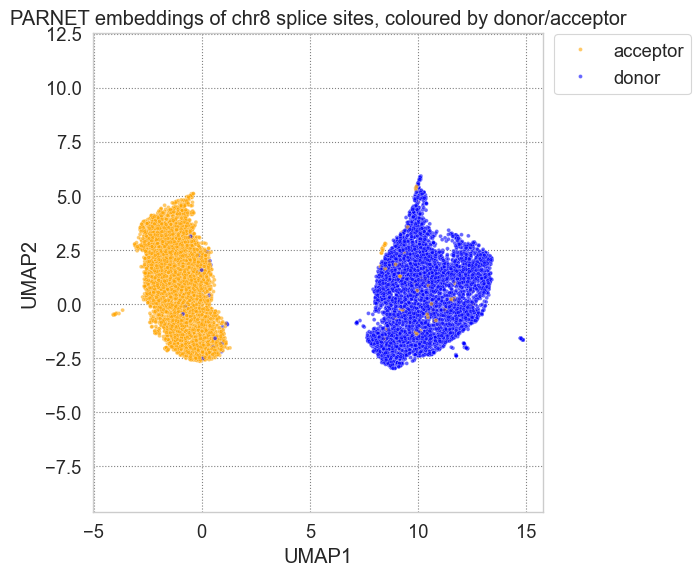

⏱ 0.17 s (00:00:00)


In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=splice_sites,
    x="UMAP1",
    y="UMAP2",
    hue="ss_type",
    palette={"donor": "blue", "acceptor": "orange"},
    s=8,
    alpha=0.6,
    ax=ax,
)
ax.set_title("PARNET embeddings of chr8 splice sites, coloured by donor/acceptor")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.1)
plt.tight_layout()
plt.show()
